# BT4221 Group Project — Feature Engineering

## Objective
This notebook performs feature engineering for the Steam review recommendation classification task.

The purpose of this notebook is not merely to create more columns, but to transform the cleaned review dataset into a representation that is more predictive, interpretable, and aligned with the patterns discovered during exploratory data analysis (EDA).

In particular, the EDA suggested several important findings:

1. Many numeric variables, especially playtime and vote-related variables, are heavily right-skewed.
2. Some binary variables are informative, but not all of them contribute equally.
3. Game-level context matters, because recommendation behaviour differs noticeably across apps.
4. Review text is likely one of the strongest signal sources.
5. Some raw columns are not useful in their original form, but become valuable after transformation, interaction construction, or aggregation.

Therefore, the feature engineering strategy in this notebook is designed around five feature families:

- behavioural features
- engagement and vote features
- game-level contextual features
- text structure and lexical features
- LLM-assisted semantic text features using OpenAI API

## Motivations
This notebook is designed to support stronger performance under the project rubric by showing:

- clearly justified feature design choices instead of arbitrary transformations
- direct linkage between EDA findings and engineering decisions
- meaningful PySpark-based execution rather than only conceptual discussion
- interpretable and data-driven insights rather than black-box feature generation
- evidence of AI-assisted pipeline enhancement through OpenAI-generated structured text features

## Important methodological principle
To avoid data leakage, any aggregate feature that depends on the target distribution, such as app-level recommendation rate, must be computed on the training split only and then mapped into validation/test data.

This is important because leakage would inflate model performance and weaken the credibility of the project.

In [1]:
# ============================================
# 1. Environment setup
# ============================================

import os
import re
import json
import math
import ast
from typing import List, Dict

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql.window import Window

from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler,
    StandardScaler,
    Tokenizer,
    StopWordsRemover,
    CountVectorizer,
    IDF,
    HashingTF
)

from pyspark.ml import Pipeline

spark = SparkSession.builder \
    .appName("BT4221_Feature_Engineering") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/10 17:05:22 WARN Utils: Your hostname, Kens-MacBook-Pro-16.local, resolves to a loopback address: 127.0.0.1; using 192.168.18.169 instead (on interface en0)
26/04/10 17:05:22 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/10 17:05:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [2]:
# ============================================
# 2. Load cleaned dataset
# ============================================

#raw_path = r"C:\Justin Folder\UNI\projects\bt4221\BT4221-Project-Steam-Reviews\cleaned_steam_reviews.csv"
raw_path = '/Users/kenzverylayz/Downloads/cleaned_steam_reviews.csv'
raw_df = spark.read.csv(
    raw_path,
    header=True,
    inferSchema=False,
    multiLine=True,
    escape='"'
)

print("Rows:", raw_df.count())
print("Columns:", len(raw_df.columns))
raw_df.printSchema()
raw_df.show(5, truncate=False)

Rows: 2091978
Columns: 22
root
 |-- app_id: string (nullable = true)
 |-- app_name: string (nullable = true)
 |-- review_id: string (nullable = true)
 |-- language: string (nullable = true)
 |-- review: string (nullable = true)
 |-- timestamp_created: string (nullable = true)
 |-- timestamp_updated: string (nullable = true)
 |-- recommended: string (nullable = true)
 |-- votes_helpful: string (nullable = true)
 |-- votes_funny: string (nullable = true)
 |-- weighted_vote_score: string (nullable = true)
 |-- comment_count: string (nullable = true)
 |-- steam_purchase: string (nullable = true)
 |-- received_for_free: string (nullable = true)
 |-- written_during_early_access: string (nullable = true)
 |-- author_steamid: string (nullable = true)
 |-- author_num_games_owned: string (nullable = true)
 |-- author_num_reviews: string (nullable = true)
 |-- author_playtime_forever: string (nullable = true)
 |-- author_playtime_last_two_weeks: string (nullable = true)
 |-- author_playtime_at_re

In [3]:
expected_cols = [
    "app_id", "app_name", "review_id", "language", "review",
    "timestamp_created", "timestamp_updated", "recommended",
    "votes_helpful", "votes_funny", "weighted_vote_score",
    "comment_count", "steam_purchase", "received_for_free",
    "written_during_early_access", "author_steamid",
    "author_num_games_owned", "author_num_reviews",
    "author_playtime_forever", "author_playtime_last_two_weeks",
    "author_playtime_at_review", "author_last_played"
]

print("Actual columns:")
print(raw_df.columns)

missing_cols = [c for c in expected_cols if c not in raw_df.columns]
extra_cols = [c for c in raw_df.columns if c not in expected_cols]

print("Missing cols:", missing_cols)
print("Extra cols:", extra_cols)

Actual columns:
['app_id', 'app_name', 'review_id', 'language', 'review', 'timestamp_created', 'timestamp_updated', 'recommended', 'votes_helpful', 'votes_funny', 'weighted_vote_score', 'comment_count', 'steam_purchase', 'received_for_free', 'written_during_early_access', 'author_steamid', 'author_num_games_owned', 'author_num_reviews', 'author_playtime_forever', 'author_playtime_last_two_weeks', 'author_playtime_at_review', 'author_last_played']
Missing cols: []
Extra cols: []


### Why audit before casting?

The dataset is first loaded entirely as strings to preserve the raw contents and avoid premature type conversion errors. This is especially important for review datasets, where multiline text, quotes, and malformed records can cause row shifts or invalid values.

Auditing the raw dataset first improves traceability and allows us to justify all later cleaning and casting decisions based on actual observed distributions rather than assumptions.

In [4]:
raw_df.select(
    F.count("*").alias("total_rows"),

    F.count(F.when(F.col("review").isNull(), 1)).alias("review_null"),
    F.count(F.when(F.trim(F.col("review")) == "", 1)).alias("review_blank"),

    F.count(F.when(F.col("app_name").isNull(), 1)).alias("app_name_null"),
    F.count(F.when(F.trim(F.col("app_name")) == "", 1)).alias("app_name_blank"),

    F.count(F.when(F.col("recommended").isNull(), 1)).alias("recommended_null"),
    F.count(F.when(~F.col("recommended").isin("0", "1"), 1)).alias("recommended_invalid")
).show(truncate=False)

print("Recommended distribution:")
raw_df.groupBy("recommended").count().orderBy(F.desc("count")).show(20, truncate=False)

+----------+-----------+------------+-------------+--------------+----------------+-------------------+
|total_rows|review_null|review_blank|app_name_null|app_name_blank|recommended_null|recommended_invalid|
+----------+-----------+------------+-------------+--------------+----------------+-------------------+
|2091978   |358        |0           |0            |0             |0               |0                  |
+----------+-----------+------------+-------------+--------------+----------------+-------------------+

Recommended distribution:


+-----------+-------+
|recommended|count  |
+-----------+-------+
|0          |1046517|
|1          |1045461|
+-----------+-------+



In [5]:
df = raw_df.select(
    F.col("app_id").cast("string").alias("app_id"),
    F.col("app_name").cast("string").alias("app_name"),
    F.col("review_id").cast("string").alias("review_id"),
    F.col("language").cast("string").alias("language"),
    F.col("review").cast("string").alias("review"),
    F.expr("try_cast(timestamp_created as long)").alias("timestamp_created"),
    F.expr("try_cast(timestamp_updated as long)").alias("timestamp_updated"),
    F.expr("try_cast(recommended as int)").alias("recommended"),
    F.expr("try_cast(votes_helpful as double)").alias("votes_helpful"),
    F.expr("try_cast(votes_funny as double)").alias("votes_funny"),
    F.expr("try_cast(weighted_vote_score as double)").alias("weighted_vote_score"),
    F.expr("try_cast(comment_count as double)").alias("comment_count"),
    F.expr("try_cast(steam_purchase as int)").alias("steam_purchase"),
    F.expr("try_cast(received_for_free as int)").alias("received_for_free"),
    F.expr("try_cast(written_during_early_access as int)").alias("written_during_early_access"),
    F.col("author_steamid").cast("string").alias("author_steamid"),
    F.expr("try_cast(author_num_games_owned as double)").alias("author_num_games_owned"),
    F.expr("try_cast(author_num_reviews as double)").alias("author_num_reviews"),
    F.expr("try_cast(author_playtime_forever as double)").alias("author_playtime_forever"),
    F.expr("try_cast(author_playtime_last_two_weeks as double)").alias("author_playtime_last_two_weeks"),
    F.expr("try_cast(author_playtime_at_review as double)").alias("author_playtime_at_review"),
    F.expr("try_cast(author_last_played as double)").alias("author_last_played")
)

print("Rows after cast:", df.count())

Rows after cast: 2091978


In [6]:
invalid_condition = (
    F.col("review").isNull() |
    (F.trim(F.col("review")) == "") |
    F.col("app_name").isNull() |
    (F.trim(F.col("app_name")) == "") |
    F.col("recommended").isNull() |
    (~F.col("recommended").isin(0, 1))
)

print("Rows to be removed:", df.filter(invalid_condition).count())
print("Rows kept:", df.filter(~invalid_condition).count())

Rows to be removed: 358


Rows kept: 2091620


In [7]:
df = df.filter(~invalid_condition)

print("Final rows after basic filter:", df.count())
df.show(5, truncate=False)

Final rows after basic filter: 2091620
+------+------------------------------+---------+--------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------+-----------------+-----------+-------------+-----------+-------------------+-------------+--------------+-----------------+---------------------------+-----------------+----------------------+------------------+-----------------------+------------------------------+-------------------------+------------------+
|app_id|app_name                      |review_id|language|review                                                                                

In [8]:
print("Recommended distribution:")
df.groupBy("recommended").count().orderBy(F.desc("count")).show(20, truncate=False)

Recommended distribution:


+-----------+-------+
|recommended|count  |
+-----------+-------+
|0          |1046438|
|1          |1045182|
+-----------+-------+



## 4.1 Train-validation split before feature engineering

Before constructing the engineered feature set, we first split the cleaned dataset into training and validation sets. This is done early because some later feature engineering steps are leakage-sensitive.

In particular, app-level aggregate features and TF-IDF involve learning information from the data. If those transformations are fitted on the full dataset before splitting, information from the validation set would leak into the training pipeline and make downstream performance estimates overly optimistic.

To keep the pipeline methodologically sound, the split is performed first, and all learned or target-derived transformations are subsequently fitted only on the training data before being applied to the validation set.

In [9]:
train_df, valid_df = df.randomSplit([0.8, 0.2], seed=42)

print("Train rows:", train_df.count())
print("Valid rows:", valid_df.count())

print("Train target distribution")
train_df.groupBy("recommended").count().show()

print("Validation target distribution")
valid_df.groupBy("recommended").count().show()

Train rows: 1673305


Valid rows: 418315
Train target distribution


+-----------+------+
|recommended| count|
+-----------+------+
|          1|836005|
|          0|837300|
+-----------+------+

Validation target distribution


+-----------+------+
|recommended| count|
+-----------+------+
|          1|209177|
|          0|209138|
+-----------+------+



## 4.2 Text structure features

The EDA suggested that review text is likely one of the most important sources of predictive signal. However, useful text information is not limited to vocabulary alone. Even before applying TF-IDF or semantic models, the structure of a review can already capture meaningful differences between positive and negative reviews.

For example, review length, punctuation intensity, and sentence structure may reflect:
- how much effort was put into the review
- whether the review is emotional or detailed
- whether it is a short impulsive reaction or a fuller evaluation

We therefore begin by engineering dense text-structure features that are interpretable and easy to explain in the report.

In [10]:
def add_text_structure_features(input_df):
    return input_df.withColumn("review_char_count", F.length("review")) \
        .withColumn("review_word_count", F.size(F.split(F.trim(F.col("review")), r"\s+"))) \
        .withColumn("review_sentence_count", F.size(F.split(F.col("review"), r"[.!?]+"))) \
        .withColumn("exclamation_count", F.length("review") - F.length(F.regexp_replace("review", "!", ""))) \
        .withColumn("question_count", F.length("review") - F.length(F.regexp_replace("review", r"\?", ""))) \
        .withColumn("digit_count", F.length("review") - F.length(F.regexp_replace("review", r"[0-9]", ""))) \
        .withColumn("has_exclamation", F.when(F.col("exclamation_count") > 0, 1).otherwise(0)) \
        .withColumn("has_question", F.when(F.col("question_count") > 0, 1).otherwise(0)) \
        .withColumn("long_review_flag", F.when(F.col("review_word_count") >= 100, 1).otherwise(0)) \
        .withColumn("very_short_review_flag", F.when(F.col("review_word_count") <= 10, 1).otherwise(0)) \
        .withColumn(
            "avg_sentence_length",
            F.when(F.col("review_sentence_count") > 0,
                   F.col("review_word_count") / F.col("review_sentence_count"))
             .otherwise(F.lit(0.0))
        )

train_df = add_text_structure_features(train_df)
valid_df = add_text_structure_features(valid_df)

train_df.select(
    "review_char_count",
    "review_word_count",
    "review_sentence_count",
    "exclamation_count",
    "question_count",
    "avg_sentence_length"
).show(5, truncate=False)

+-----------------+-----------------+---------------------+-----------------+--------------+-------------------+
|review_char_count|review_word_count|review_sentence_count|exclamation_count|question_count|avg_sentence_length|
+-----------------+-----------------+---------------------+-----------------+--------------+-------------------+
|318              |60               |4                    |0                |0             |15.0               |
|890              |155              |16                   |0                |0             |9.6875             |
|1610             |286              |115                  |114              |0             |2.4869565217391303 |
|713              |131              |9                    |0                |0             |14.555555555555555 |
|100              |21               |2                    |0                |1             |10.5               |
+-----------------+-----------------+---------------------+-----------------+--------------+----

### Why these text structure features are justified

These features are justified because they convert the raw review into interpretable behavioural signals. In particular:

- `review_char_count` and `review_word_count` measure review length and effort
- `review_sentence_count` and `avg_sentence_length` measure how developed or fragmented the review is
- `exclamation_count` and `question_count` measure emphasis or frustration
- `long_review_flag` and `very_short_review_flag` help isolate extreme review styles

This is especially helpful for the rubric because these features are not black-box transformations. They can be clearly explained, visualised, and later discussed in relation to model performance and review behaviour.

## 4.3 Missingness indicators

Some metadata fields may be missing, and that missingness can itself carry signal. For example, the absence of playtime or vote-related metadata may reflect differences in review history, review age, or platform behaviour.

To preserve that information, we create missingness flags before filling nulls for downstream numeric transformations. This allows the modelling stage to distinguish between a true zero and an originally missing value.

In [11]:
missing_flag_cols = [
    "votes_helpful",
    "votes_funny",
    "weighted_vote_score",
    "comment_count",
    "author_num_games_owned",
    "author_num_reviews",
    "author_playtime_forever",
    "author_playtime_last_two_weeks",
    "author_playtime_at_review",
    "author_last_played"
]

def add_missing_flags(input_df, cols):
    out = input_df
    for c in cols:
        if c in out.columns:
            out = out.withColumn(f"{c}_missing", F.when(F.col(c).isNull(), 1).otherwise(0))
    return out

train_df = add_missing_flags(train_df, missing_flag_cols)
valid_df = add_missing_flags(valid_df, missing_flag_cols)

## 4.3 Log-transform skewed numeric features

The EDA indicated that many numeric variables are strongly right-skewed. This is particularly common for online review data, where most observations are small but a few reviews or users have extremely large values.

This matters because raw skewed variables can distort modelling by allowing extreme observations to dominate the scale. Rather than discarding such columns, a better approach is to retain them but transform them into a more stable form.

We therefore apply a `log1p` transformation to key engagement and playtime-related features.

In [12]:
log_numeric_cols = [
    "votes_helpful",
    "votes_funny",
    "comment_count",
    "author_num_games_owned",
    "author_num_reviews",
    "author_playtime_forever",
    "author_playtime_last_two_weeks",
    "author_playtime_at_review"
]

def add_log_features(input_df, cols):
    out = input_df
    for c in cols:
        if c in out.columns:
            out = out.withColumn(f"log1p_{c}", F.log1p(F.coalesce(F.col(c), F.lit(0))))
    return out

train_df = add_log_features(train_df, log_numeric_cols)
valid_df = add_log_features(valid_df, log_numeric_cols)

train_df.select(
    "votes_helpful", "log1p_votes_helpful",
    "author_playtime_forever", "log1p_author_playtime_forever"
).show(5, truncate=False)

+-------------+-------------------+-----------------------+-----------------------------+
|votes_helpful|log1p_votes_helpful|author_playtime_forever|log1p_author_playtime_forever|
+-------------+-------------------+-----------------------+-----------------------------+
|4.0          |1.6094379124341003 |67.0                   |4.219507705176107            |
|0.0          |0.0                |139.0                  |4.941642422609304            |
|7.0          |2.0794415416798357 |1459.0                 |7.286191714702382            |
|1.0          |0.6931471805599453 |108.0                  |4.6913478822291435           |
|3.0          |1.3862943611198906 |2086.0                 |7.643482907077201            |
+-------------+-------------------+-----------------------+-----------------------------+
only showing top 5 rows


### Why the log transformation is justified

This transformation is directly supported by the EDA. It improves the representation of skewed variables by:

- reducing the influence of extreme outliers
- preserving rank ordering
- compressing very large values into a more model-friendly scale
- keeping potentially useful variables instead of dropping them

This is a stronger feature engineering decision than either leaving the variables untouched or removing them too early.

## 4.4 Behavioural ratio features

Raw counts are useful, but they do not always capture behaviour as well as ratios do. Two users may have similar totals while behaving very differently.

To address this, we engineer several ratio-based features that reflect reviewer behaviour more directly. These help move the feature space from simple quantity to more meaningful behavioural patterns.

In [13]:
def add_ratio_features(input_df):
    return input_df.withColumn(
            "funny_to_helpful_ratio",
            (F.coalesce(F.col("votes_funny"), F.lit(0)) + 1) /
            (F.coalesce(F.col("votes_helpful"), F.lit(0)) + 1)
        ).withColumn(
            "reviews_to_games_ratio",
            (F.coalesce(F.col("author_num_reviews"), F.lit(0)) + 1) /
            (F.coalesce(F.col("author_num_games_owned"), F.lit(0)) + 1)
        ).withColumn(
            "recent_to_total_playtime_ratio",
            (F.coalesce(F.col("author_playtime_last_two_weeks"), F.lit(0)) + 1) /
            (F.coalesce(F.col("author_playtime_forever"), F.lit(0)) + 1)
        ).withColumn(
            "words_per_playtime",
            (F.coalesce(F.col("review_word_count"), F.lit(0)) + 1) /
            (F.coalesce(F.col("author_playtime_at_review"), F.lit(0)) + 1)
        ).withColumn(
            "helpful_per_word",
            (F.coalesce(F.col("votes_helpful"), F.lit(0)) + 1) /
            (F.coalesce(F.col("review_word_count"), F.lit(0)) + 1)
        ).withColumn(
            "comment_per_word",
            (F.coalesce(F.col("comment_count"), F.lit(0)) + 1) /
            (F.coalesce(F.col("review_word_count"), F.lit(0)) + 1)
        ).withColumn(
            "playtime_per_game_owned",
            (F.coalesce(F.col("author_playtime_forever"), F.lit(0)) + 1) /
            (F.coalesce(F.col("author_num_games_owned"), F.lit(0)) + 1)
        )

train_df = add_ratio_features(train_df)
valid_df = add_ratio_features(valid_df)

train_df.select(
    "funny_to_helpful_ratio",
    "reviews_to_games_ratio",
    "recent_to_total_playtime_ratio",
    "words_per_playtime",
    "helpful_per_word",
    "comment_per_word",
    "playtime_per_game_owned"
).show(5, truncate=False)

+----------------------+----------------------+------------------------------+-------------------+--------------------+--------------------+-----------------------+
|funny_to_helpful_ratio|reviews_to_games_ratio|recent_to_total_playtime_ratio|words_per_playtime |helpful_per_word    |comment_per_word    |playtime_per_game_owned|
+----------------------+----------------------+------------------------------+-------------------+--------------------+--------------------+-----------------------+
|0.2                   |0.024390243902439025  |0.014705882352941176          |0.9682539682539683 |0.08196721311475409 |0.01639344262295082 |0.5528455284552846     |
|1.0                   |0.08609271523178808   |0.007142857142857143          |1.1142857142857143 |0.00641025641025641 |0.00641025641025641 |0.9271523178807947     |
|1.75                  |0.06381766381766382   |6.849315068493151E-4          |1.148              |0.027874564459930314|0.003484320557491289|0.8319088319088319     |
|0.5      

### Why these ratio features are justified

These features provide additional behavioural interpretation beyond raw counts:

- `funny_to_helpful_ratio` distinguishes comedic or sarcastic reviews from useful ones
- `reviews_to_games_ratio` measures how actively a user reviews relative to how many games they own
- `recent_to_total_playtime_ratio` captures whether the review is based on recent engagement
- `words_per_playtime` approximates whether review detail is proportionate to actual play exposure

These features are useful because they reflect reviewer behaviour and review credibility in a more nuanced way than standalone counts.

## 4.5 Binary context features

The dataset contains several binary context variables such as:
- `steam_purchase`
- `received_for_free`
- `written_during_early_access`

The EDA suggested that some of these may be stronger than others. However, weaker univariate predictors should not be removed prematurely, because they may still contribute jointly with other features in multivariate models.

For this reason, we retain these binary variables as part of the engineered feature set.

In [14]:
binary_cols = ["steam_purchase", "received_for_free", "written_during_early_access"]

for c in binary_cols:
    if c in train_df.columns:
        train_df = train_df.withColumn(c, F.coalesce(F.col(c), F.lit(0)))
        valid_df = valid_df.withColumn(c, F.coalesce(F.col(c), F.lit(0)))

train_df.select(*[c for c in binary_cols if c in train_df.columns]).show(5, truncate=False)

+--------------+-----------------+---------------------------+
|steam_purchase|received_for_free|written_during_early_access|
+--------------+-----------------+---------------------------+
|1             |0                |0                          |
|1             |0                |0                          |
|1             |0                |0                          |
|1             |0                |0                          |
|1             |0                |0                          |
+--------------+-----------------+---------------------------+
only showing top 5 rows


### Why keeping weaker binary variables is still justified

A variable that looks weak on its own is not necessarily useless in the final model. For example, `received_for_free` may have limited standalone predictive power, but it can still interact with text sentiment, game type, or review length.

Retaining these variables at this stage is therefore more defensible than dropping them based only on univariate inspection.

## 4.6 Leakage-safe app-level contextual features

The EDA suggested that `app_name` is highly informative, which means game-level context is important. However, app-level statistics can easily cause leakage if they are computed using the full dataset, especially when they involve the target variable.

To avoid this, all app-level aggregates are computed on the training set only, then joined back into both the training and validation sets. This ensures that validation rows do not influence the aggregate values used during training.

In [15]:
train_app_stats = train_df.groupBy("app_name").agg(
    F.count("*").alias("app_review_count"),
    F.avg("recommended").alias("app_recommend_rate"),
    F.avg("review_word_count").alias("app_avg_review_word_count"),
    F.avg(F.coalesce(F.col("votes_helpful"), F.lit(0))).alias("app_avg_votes_helpful")
)

global_defaults = train_app_stats.agg(
    F.avg("app_review_count").alias("global_app_review_count"),
    F.avg("app_recommend_rate").alias("global_app_recommend_rate"),
    F.avg("app_avg_review_word_count").alias("global_app_avg_review_word_count"),
    F.avg("app_avg_votes_helpful").alias("global_app_avg_votes_helpful")
).collect()[0]

train_df = train_df.join(train_app_stats, on="app_name", how="left")
valid_df = valid_df.join(train_app_stats, on="app_name", how="left")

train_df = train_df.fillna({
    "app_review_count": global_defaults["global_app_review_count"],
    "app_recommend_rate": global_defaults["global_app_recommend_rate"],
    "app_avg_review_word_count": global_defaults["global_app_avg_review_word_count"],
    "app_avg_votes_helpful": global_defaults["global_app_avg_votes_helpful"]
})

valid_df = valid_df.fillna({
    "app_review_count": global_defaults["global_app_review_count"],
    "app_recommend_rate": global_defaults["global_app_recommend_rate"],
    "app_avg_review_word_count": global_defaults["global_app_avg_review_word_count"],
    "app_avg_votes_helpful": global_defaults["global_app_avg_votes_helpful"]
})

train_df.select(
    "app_name",
    "app_review_count",
    "app_recommend_rate",
    "app_avg_review_word_count",
    "app_avg_votes_helpful"
).show(5, truncate=False)

+--------+----------------+-------------------+-------------------------+---------------------+
|app_name|app_review_count|app_recommend_rate |app_avg_review_word_count|app_avg_votes_helpful|
+--------+----------------+-------------------+-------------------------+---------------------+
|WWE 2K20|994             |0.06237424547283702|66.61569416498995        |4.240442655935614    |
|WWE 2K20|994             |0.06237424547283702|66.61569416498995        |4.240442655935614    |
|WWE 2K20|994             |0.06237424547283702|66.61569416498995        |4.240442655935614    |
|WWE 2K20|994             |0.06237424547283702|66.61569416498995        |4.240442655935614    |
|WWE 2K20|994             |0.06237424547283702|66.61569416498995        |4.240442655935614    |
+--------+----------------+-------------------+-------------------------+---------------------+
only showing top 5 rows


### Why app-level features are justified

This is one of the most important feature families in the notebook. The EDA suggested that recommendation rates vary across games, which means the model should be given access to game-level context.

The engineered app features capture:
- how widely reviewed a game is
- how positively it is received overall
- how long reviews tend to be for that game
- how much helpful engagement that game’s reviews receive

This is more informative than simply passing the raw `app_name` into the model, because it translates the categorical label into interpretable contextual signals.

## 4.9 Temporal and edit-history features

The dataset contains timestamp metadata that can be used to capture when the review was created, whether it was edited later, and how recent the player’s last-played activity was relative to the review.

These features are useful because they may reflect:
- review timing in the game lifecycle
- whether the user returned to revise the review
- whether the review was written close to the player’s most recent engagement

In [16]:
def add_time_features(input_df):
    out = input_df.withColumn("created_ts", F.from_unixtime(F.col("timestamp_created")).cast("timestamp")) \
        .withColumn("updated_ts", F.from_unixtime(F.col("timestamp_updated")).cast("timestamp")) \
        .withColumn("last_played_ts", F.from_unixtime(F.col("author_last_played")).cast("timestamp")) \
        .withColumn("created_year", F.year("created_ts")) \
        .withColumn("created_month", F.month("created_ts")) \
        .withColumn("created_dayofweek", F.dayofweek("created_ts")) \
        .withColumn("is_weekend_review", F.when(F.col("created_dayofweek").isin(1, 7), 1).otherwise(0)) \
        .withColumn(
            "review_edit_gap_seconds",
            F.when(
                F.col("timestamp_updated").isNotNull() & F.col("timestamp_created").isNotNull(),
                F.col("timestamp_updated") - F.col("timestamp_created")
            ).otherwise(None)
        ).withColumn(
            "review_edited_flag",
            F.when(
                F.col("timestamp_updated").isNotNull() &
                F.col("timestamp_created").isNotNull() &
                (F.col("timestamp_updated") > F.col("timestamp_created")),
                1
            ).otherwise(0)
        ).withColumn(
            "time_since_last_played_seconds",
            F.when(
                F.col("timestamp_created").isNotNull() &
                F.col("author_last_played").isNotNull(),
                F.col("timestamp_created") - F.col("author_last_played")
            ).otherwise(None)
        )

    out = out.withColumn("review_edit_gap_seconds", F.coalesce(F.col("review_edit_gap_seconds"), F.lit(0))) \
             .withColumn("time_since_last_played_seconds", F.coalesce(F.col("time_since_last_played_seconds"), F.lit(0)))

    return out

train_df = add_time_features(train_df)
valid_df = add_time_features(valid_df)

train_df.select(
    "created_year",
    "created_month",
    "created_dayofweek",
    "is_weekend_review",
    "review_edit_gap_seconds",
    "review_edited_flag",
    "time_since_last_played_seconds"
).show(5, truncate=False)

+------------+-------------+-----------------+-----------------+-----------------------+------------------+------------------------------+
|created_year|created_month|created_dayofweek|is_weekend_review|review_edit_gap_seconds|review_edited_flag|time_since_last_played_seconds|
+------------+-------------+-----------------+-----------------+-----------------------+------------------+------------------------------+
|2019        |10           |4                |0                |0                      |0                 |-2.9319079E7                  |
|2019        |10           |4                |0                |0                      |0                 |702.0                         |
|2019        |10           |4                |0                |0                      |0                 |-8013262.0                    |
|2019        |10           |4                |0                |0                      |0                 |36897.0                       |
|2019        |10           

### Why temporal features are justified

Temporal features are relatively cheap to create and can still be useful because they capture:
- the timing of a review in the game lifecycle
- possible weekday versus weekend behavioural differences
- longer-run temporal shifts in review patterns

Even if their predictive contribution is modest, they are interpretable and worth including as part of a well-rounded feature set.

## 4.11 Leakage-safe TF-IDF text features

Sparse lexical text features are retained because the EDA suggested that review text is highly informative. While the text-structure features above capture how a review is written, TF-IDF captures what is being said.

To keep the transformation leakage-safe, the IDF component is fitted on the training set only, and the fitted model is then applied to both training and validation data.

In [17]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF

tokenizer = Tokenizer(inputCol="review", outputCol="tokens_raw")
remover = StopWordsRemover(inputCol="tokens_raw", outputCol="tokens_clean")
hashing_tf = HashingTF(inputCol="tokens_clean", outputCol="tf_features", numFeatures=5000)
idf = IDF(inputCol="tf_features", outputCol="tfidf_features")

train_df = tokenizer.transform(train_df)
valid_df = tokenizer.transform(valid_df)

train_df = remover.transform(train_df)
valid_df = remover.transform(valid_df)

train_df = hashing_tf.transform(train_df)
valid_df = hashing_tf.transform(valid_df)

idf_model = idf.fit(train_df)

train_df = idf_model.transform(train_df)
valid_df = idf_model.transform(valid_df)

train_df.select("tokens_clean", "tfidf_features").show(3, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### Why TF-IDF is justified

TF-IDF complements the earlier dense text features in an important way:

- dense text features capture **how** a review is written
- TF-IDF captures **what** a review is saying

This gives the model a richer text representation and is more defensible than relying on review length alone. It also aligns well with the project objective of extracting meaningful predictive information from text-heavy review data.

## 4.12 Final engineered dense feature list

To make the feature engineering output reproducible and easy to hand over for downstream modelling, we explicitly define the dense engineered feature set produced in this notebook.

This is separate from the sparse lexical representation in `tfidf_features`.

In [18]:
dense_feature_cols = [
    "review_char_count",
    "review_word_count",
    "review_sentence_count",
    "exclamation_count",
    "question_count",
    "digit_count",
    "has_exclamation",
    "has_question",
    "long_review_flag",
    "very_short_review_flag",
    "avg_sentence_length",

    "log1p_votes_helpful",
    "log1p_votes_funny",
    "log1p_comment_count",
    "log1p_author_num_games_owned",
    "log1p_author_num_reviews",
    "log1p_author_playtime_forever",
    "log1p_author_playtime_last_two_weeks",
    "log1p_author_playtime_at_review",

    "weighted_vote_score_filled",

    "funny_to_helpful_ratio",
    "reviews_to_games_ratio",
    "recent_to_total_playtime_ratio",
    "words_per_playtime",
    "helpful_per_word",
    "comment_per_word",
    "playtime_per_game_owned",

    "steam_purchase",
    "received_for_free",
    "written_during_early_access",

    "created_year",
    "created_month",
    "created_dayofweek",
    "is_weekend_review",
    "review_edit_gap_seconds",
    "review_edited_flag",
    "time_since_last_played_seconds",

    "app_review_count",
    "app_recommend_rate",
    "app_avg_review_word_count",
    "app_avg_votes_helpful",

    "votes_helpful_missing",
    "votes_funny_missing",
    "weighted_vote_score_missing",
    "comment_count_missing",
    "author_num_games_owned_missing",
    "author_num_reviews_missing",
    "author_playtime_forever_missing",
    "author_playtime_last_two_weeks_missing",
    "author_playtime_at_review_missing",
    "author_last_played_missing"
]

dense_feature_cols = [c for c in dense_feature_cols if c in train_df.columns]

print("Dense feature count:", len(dense_feature_cols))
print(dense_feature_cols)

Dense feature count: 50
['review_char_count', 'review_word_count', 'review_sentence_count', 'exclamation_count', 'question_count', 'digit_count', 'has_exclamation', 'has_question', 'long_review_flag', 'very_short_review_flag', 'avg_sentence_length', 'log1p_votes_helpful', 'log1p_votes_funny', 'log1p_comment_count', 'log1p_author_num_games_owned', 'log1p_author_num_reviews', 'log1p_author_playtime_forever', 'log1p_author_playtime_last_two_weeks', 'log1p_author_playtime_at_review', 'funny_to_helpful_ratio', 'reviews_to_games_ratio', 'recent_to_total_playtime_ratio', 'words_per_playtime', 'helpful_per_word', 'comment_per_word', 'playtime_per_game_owned', 'steam_purchase', 'received_for_free', 'written_during_early_access', 'created_year', 'created_month', 'created_dayofweek', 'is_weekend_review', 'review_edit_gap_seconds', 'review_edited_flag', 'time_since_last_played_seconds', 'app_review_count', 'app_recommend_rate', 'app_avg_review_word_count', 'app_avg_votes_helpful', 'votes_helpful_m

## 4.13 Output of the feature engineering stage

At the end of this section, the feature engineering stage produces:

- `train_df`, containing the training split with engineered dense features and sparse TF-IDF text features
- `valid_df`, containing the validation split transformed using the same leakage-safe feature logic
- `dense_feature_cols`, which explicitly lists the engineered dense features for downstream modelling
- `tfidf_features`, which stores the sparse lexical text representation

This provides a clean and modelling-ready handoff for the downstream training and evaluation stage.

In [19]:
print("Train rows after FE:", train_df.count())
print("Valid rows after FE:", valid_df.count())

train_df.select("recommended", *dense_feature_cols[:10]).show(5, truncate=False)
valid_df.select("recommended", *dense_feature_cols[:10]).show(5, truncate=False)

Train rows after FE: 1673305


Valid rows after FE: 418315


+-----------+-----------------+-----------------+---------------------+-----------------+--------------+-----------+---------------+------------+----------------+----------------------+
|recommended|review_char_count|review_word_count|review_sentence_count|exclamation_count|question_count|digit_count|has_exclamation|has_question|long_review_flag|very_short_review_flag|
+-----------+-----------------+-----------------+---------------------+-----------------+--------------+-----------+---------------+------------+----------------+----------------------+
|0          |318              |60               |4                    |0                |0             |0          |0              |0           |0               |0                     |
|0          |890              |155              |16                   |0                |0             |1          |0              |0           |1               |0                     |
|0          |1610             |286              |115                  

+-----------+-----------------+-----------------+---------------------+-----------------+--------------+-----------+---------------+------------+----------------+----------------------+
|recommended|review_char_count|review_word_count|review_sentence_count|exclamation_count|question_count|digit_count|has_exclamation|has_question|long_review_flag|very_short_review_flag|
+-----------+-----------------+-----------------+---------------------+-----------------+--------------+-----------+---------------+------------+----------------+----------------------+
|0          |380              |73               |2                    |0                |0             |5          |0              |0           |0               |0                     |
|0          |851              |159              |8                    |0                |0             |0          |0              |0           |1               |0                     |
|1          |269              |46               |3                    

## X.X OpenAI-assisted semantic feature engineering

Classical text features such as TF-IDF are useful because they capture word-level patterns, but they do not always capture higher-level meaning reliably. Two reviews may describe the same issue using very different vocabulary, for example poor performance, repetitive gameplay, or strong value for money.

To address this, we add a small semantic enrichment step using the OpenAI API. The goal is not to generate free-form summaries, but to convert review text into **structured semantic features** that can be used like ordinary model inputs.

We use the model to return a fixed schema for each review, including:
- sentiment label
- sentiment strength
- main topic
- recommendation clarity
- specificity level
- whether the review mentions bugs
- whether it mentions performance
- whether it mentions value for money
- whether it mentions replayability

This approach is more defensible than vague LLM prompting because the output is structured, reproducible, and directly connected to the downstream training pipeline.

### Why this step is justified

This step is justified for three reasons.

First, it is aligned with the EDA. Earlier analysis suggested that review text is one of the strongest feature sources, so it is reasonable to invest in richer text representations.

Second, it fits the rubric well. The project brief explicitly allows and encourages meaningful AI-assisted pipeline design, especially when the outputs are structured and actually influence downstream execution.

Third, semantic features fill a gap left by TF-IDF. TF-IDF captures lexical information, but semantic labels can better capture higher-level concepts such as whether a review is mainly about bugs, performance, value, or gameplay, even when different words are used.

### Practical note on scale

The full dataset is extremely large, so applying the API to every row would be slow and expensive. For this reason, the semantic enrichment step should be run on a manageable subset.

Reasonable choices include:
- a random sample
- the training split only
- a subset of the most informative reviews
- a smaller balanced sample used for modelling

The purpose of this section is to demonstrate a valid and structured LLM-assisted feature engineering workflow, not to exhaustively process the entire raw dataset.

### API setup

We initialise the OpenAI client using an environment variable so that secrets are not hardcoded into the notebook.

In [ ]:
import os
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
    raise ValueError("OPENAI_API_KEY is not set in the environment.")

client = OpenAI(api_key=api_key)
print("API key loaded")

### Step 1: sample a manageable subset directly from Spark

Because the full dataset is too large for API enrichment, we first select a manageable subset of valid reviews. This should ideally be drawn from the training data only if the modelling pipeline is already split.

In [ ]:
llm_input_df = df.select("review_id", "review", "recommended") \
    .filter(F.col("review").isNotNull()) \
    .filter(F.trim(F.col("review")) != "") \
    .limit(1000)

print("Rows selected for LLM enrichment:", llm_input_df.count())
llm_input_df.show(5, truncate=False)

 # 5. Model Selection and Feature Importance

This section evaluates classification models for predicting whether a player recommends a game and identifies the most important predictive features. The modeling pipeline integrates both engineered dense features and TF-IDF representations of review text, allowing the model to capture both structured behavioural signals and unstructured textual information.

The workflow consists of three main steps: preprocessing of features, model selection using validation AUC, and feature importance analysis based on the final selected model.

## 5.1 Preprocessing for Model Training

Before training the models, the engineered dense features were prepared in a format compatible with Spark ML. The feature list was validated to ensure only existing columns were used, making the pipeline robust to future changes in feature engineering.

All dense features and the target variable were cast to numeric types to prevent type inconsistencies during training. Missing values were handled using mean imputation. While median imputation is generally more robust to skewed distributions, it requires computing approximate quantiles, which is computationally expensive for large-scale datasets. Given the size of the dataset and the resource constraints of the execution environment, mean imputation was adopted as a more efficient alternative. This approach provides a reasonable approximation while ensuring that preprocessing remains tractable.

In addition to the structured dense features, TF-IDF features derived from review text were incorporated. These text features provide a numerical representation of the semantic content of reviews.

Finally, all imputed dense features and TF-IDF features were combined into a single feature vector using `VectorAssembler`, which is required for Spark ML models.

In [20]:
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import Imputer, VectorAssembler
from pyspark.ml import Pipeline

SEED = 42
LABEL_COL = "recommended"
TEXT_FEATURE_COL = "tfidf_features"

# Validate feature columns
feature_cols = [c for c in dense_feature_cols if c in train_df.columns and c in valid_df.columns]

print("Number of dense features:", len(feature_cols))

# Cast dense features
for c in feature_cols:
    train_df = train_df.withColumn(c, F.col(c).cast(DoubleType()))
    valid_df = valid_df.withColumn(c, F.col(c).cast(DoubleType()))

# Cast label
train_df = train_df.withColumn(LABEL_COL, F.col(LABEL_COL).cast(DoubleType()))
valid_df = valid_df.withColumn(LABEL_COL, F.col(LABEL_COL).cast(DoubleType()))

# Imputation
imputed_cols = [f"{c}_imp" for c in feature_cols]

imputer = Imputer(
    inputCols=feature_cols,
    outputCols=imputed_cols,
    strategy="mean"
)

# Combine dense + TF-IDF
assembler = VectorAssembler(
    inputCols=imputed_cols + [TEXT_FEATURE_COL],
    outputCol="features",
    handleInvalid="skip"
)

Number of dense features: 50


## 5.2 Model Selection Framework

Two models were evaluated: Logistic Regression and Random Forest. Logistic Regression was used as a baseline model due to its simplicity and interpretability, while Random Forest was chosen as a more flexible model capable of capturing nonlinear relationships and interactions.

Both models were trained using the same preprocessing pipeline to ensure a fair comparison. Model performance was evaluated using Area Under the ROC Curve (AUC) on the validation set.

## 5.3 Logistic Regression Model

Logistic Regression was trained as the baseline classifier and tuned to improve predictive performance. To ensure computational efficiency, preprocessing steps such as imputation and feature assembly were performed outside the model fitting stage. The imputer was fitted once on the training dataset and applied consistently to both training and validation datasets.

Manual hyperparameter tuning was then performed by varying the regularization strength (`regParam`) and the elastic net mixing parameter (`elasticNetParam`). This allowed different levels and types of regularization to be evaluated without the computational overhead of full cross-validation. Each candidate model was trained on the same processed training dataset and evaluated on the validation dataset using AUC. The best-performing configuration was selected as the final Logistic Regression model.

In [ ]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import pandas as pd

# Step 1: Fit imputer ONCE

imputer_model = imputer.fit(train_df)

train_lr_df = imputer_model.transform(train_df)
valid_lr_df = imputer_model.transform(valid_df)

# Step 2: Assemble features ONCE

train_lr_df = assembler.transform(train_lr_df)
valid_lr_df = assembler.transform(valid_lr_df)

# Keep only required columns
train_lr_df = train_lr_df.select(LABEL_COL, "features")
valid_lr_df = valid_lr_df.select(LABEL_COL, "features")

# Step 3: Define evaluator

evaluator = BinaryClassificationEvaluator(
    labelCol=LABEL_COL,
    metricName="areaUnderROC"
)

# Step 4: Manual tuning grid

lr_configs = [
    {"maxIter": 20, "regParam": 0.0,  "elasticNetParam": 0.0},
    {"maxIter": 20, "regParam": 0.01, "elasticNetParam": 0.0},
    {"maxIter": 20, "regParam": 0.1,  "elasticNetParam": 0.0},
    {"maxIter": 20, "regParam": 0.01, "elasticNetParam": 0.5},
    {"maxIter": 20, "regParam": 0.1,  "elasticNetParam": 0.5},
    {"maxIter": 20, "regParam": 0.01, "elasticNetParam": 1.0},
]

lr_results = []

for config in lr_configs:
    lr = LogisticRegression(
        featuresCol="features",
        labelCol=LABEL_COL,
        maxIter=config["maxIter"],
        regParam=config["regParam"],
        elasticNetParam=config["elasticNetParam"]
    )
    
    model = lr.fit(train_lr_df)
    preds = model.transform(valid_lr_df)
    auc = evaluator.evaluate(preds)
    
    lr_results.append({
        "maxIter": config["maxIter"],
        "regParam": config["regParam"],
        "elasticNetParam": config["elasticNetParam"],
        "validation_auc": float(auc),
        "fitted_model": model
    })

# Step 5: Compare tuning results

lr_results_df = pd.DataFrame(lr_results).sort_values(
    "validation_auc", ascending=False
).reset_index(drop=True)

display(lr_results_df.drop(columns=["fitted_model"]))

# Step 6: Select best model

lr_model = lr_results_df.loc[0, "fitted_model"]
lr_auc = lr_results_df.loc[0, "validation_auc"]
lr_best_max_iter = lr_results_df.loc[0, "maxIter"]
lr_best_reg_param = lr_results_df.loc[0, "regParam"]
lr_best_elastic_net = lr_results_df.loc[0, "elasticNetParam"]

print(f"Selected Logistic Regression AUC: {lr_auc:.4f}")
print(f"Best maxIter: {lr_best_max_iter}")
print(f"Best regParam: {lr_best_reg_param}")
print(f"Best elasticNetParam: {lr_best_elastic_net}")

,maxIter,regParam,elasticNetParam,validation_auc
0,20,0.00,0.0,0.939317
1,20,0.01,0.0,0.936815
2,20,0.10,0.0,0.928136
3,20,0.01,0.5,0.911929
4,20,0.01,1.0,0.897194
5,20,0.10,0.5,0.852874


Selected Logistic Regression AUC: 0.9393
Best maxIter: 20
Best regParam: 0.0
Best elasticNetParam: 0.0


The `regParam` controls the strength of regularization, with higher values imposing a stronger penalty on the coefficients. The `elasticNetParam` controls the type of regularization applied: `0` corresponds to pure L2 regularization, `1` corresponds to pure L1 regularization, and intermediate values combine both penalties.

## 5.4 Random Forest Model

Random Forest was trained as the main nonlinear benchmark model. Unlike Logistic Regression, Random Forest can capture nonlinear relationships and interactions across structured behavioural features and textual TF-IDF signals.

Due to the computational cost of repeated pipeline fitting, a manual tuning approach was adopted instead of full cross-validation. Specifically, a small set of candidate hyperparameter combinations was evaluated by varying the maximum tree depth and the feature subset strategy. The maximum depth controls the complexity of each tree, while the feature subset strategy determines how many candidate predictors are considered at each split.

To improve efficiency, preprocessing steps such as imputation and feature assembly were performed once before model tuning. Each Random Forest configuration was then trained on the same processed training data and evaluated on the validation dataset using AUC. The best-performing configuration was selected as the final Random Forest model.

In [ ]:
from pyspark.ml.classification import RandomForestClassifier
import pandas as pd

# Step 1: fit imputer once on training data

imputer_model = imputer.fit(train_df)

train_rf_df = imputer_model.transform(train_df)
valid_rf_df = imputer_model.transform(valid_df)

# Step 2: assemble features once

train_rf_df = assembler.transform(train_rf_df)
valid_rf_df = assembler.transform(valid_rf_df)

train_rf_df = train_rf_df.select(LABEL_COL, "features")
valid_rf_df = valid_rf_df.select(LABEL_COL, "features")

# Step 3: manually test a few RF configurations
rf_configs = [
    {"numTrees": 100, "maxDepth": 5,  "featureSubsetStrategy": "sqrt"},
    {"numTrees": 100, "maxDepth": 10, "featureSubsetStrategy": "sqrt"},
    {"numTrees": 100, "maxDepth": 5,  "featureSubsetStrategy": "log2"},
    {"numTrees": 100, "maxDepth": 10, "featureSubsetStrategy": "log2"},
]

rf_results = []

for config in rf_configs:
    rf = RandomForestClassifier(
        featuresCol="features",
        labelCol=LABEL_COL,
        seed=SEED,
        numTrees=config["numTrees"],
        maxDepth=config["maxDepth"],
        featureSubsetStrategy=config["featureSubsetStrategy"]
    )
    
    model = rf.fit(train_rf_df)
    preds = model.transform(valid_rf_df)
    auc = evaluator.evaluate(preds)
    
    rf_results.append({
        "numTrees": config["numTrees"],
        "maxDepth": config["maxDepth"],
        "featureSubsetStrategy": config["featureSubsetStrategy"],
        "validation_auc": auc,
        "fitted_model": model
    })
# Step 4: compare results and select best model

rf_results_df = pd.DataFrame(rf_results).sort_values(
    "validation_auc", ascending=False
).reset_index(drop=True)

display(rf_results_df.drop(columns=["fitted_model"]))

rf_model = rf_results_df.loc[0, "fitted_model"]
rf_auc = rf_results_df.loc[0, "validation_auc"]
rf_best_depth = rf_results_df.loc[0, "maxDepth"]
rf_best_feature_subset = rf_results_df.loc[0, "featureSubsetStrategy"]
rf_best_num_trees = rf_results_df.loc[0, "numTrees"]

print(f"Selected Random Forest AUC: {rf_auc:.4f}")
print(f"Best numTrees: {rf_best_num_trees}")
print(f"Best maxDepth: {rf_best_depth}")
print(f"Best featureSubsetStrategy: {rf_best_feature_subset}")

26/04/10 17:22:20 WARN DAGScheduler: Broadcasting large task binary with size 1033.6 KiB
26/04/10 17:22:22 WARN MemoryStore: Not enough space to cache rdd_694_11 in memory! (computed 355.1 MiB so far)
26/04/10 17:22:22 WARN BlockManager: Persisting block rdd_694_11 to disk instead.
26/04/10 17:22:22 WARN MemoryStore: Not enough space to cache rdd_694_9 in memory! (computed 355.1 MiB so far)
26/04/10 17:22:22 WARN BlockManager: Persisting block rdd_694_9 to disk instead.
26/04/10 17:22:22 WARN MemoryStore: Not enough space to cache rdd_694_7 in memory! (computed 228.5 MiB so far)
26/04/10 17:22:22 WARN BlockManager: Persisting block rdd_694_7 to disk instead.
26/04/10 17:22:22 WARN MemoryStore: Not enough space to cache rdd_694_0 in memory! (computed 355.1 MiB so far)
26/04/10 17:22:22 WARN BlockManager: Persisting block rdd_694_0 to disk instead.
26/04/10 17:22:22 WARN MemoryStore: Not enough space to cache rdd_694_13 in memory! (computed 355.1 MiB so far)
26/04/10 17:22:22 WARN BlockM

,numTrees,maxDepth,featureSubsetStrategy,validation_auc
0,100,10,sqrt,0.874632
1,100,5,sqrt,0.836945
2,100,10,log2,0.820659
3,100,5,log2,0.816697


Selected Random Forest AUC: 0.8746
Best numTrees: 100
Best maxDepth: 10
Best featureSubsetStrategy: sqrt


## 5.5 Model Comparison

To evaluate model performance, Logistic Regression and Random Forest were compared using the Area Under the Receiver Operating Characteristic Curve (AUC) on the validation dataset. AUC was selected as the primary evaluation metric as it provides a threshold-independent measure of a model’s ability to distinguish between recommended and non-recommended reviews.

Both models were tuned to ensure a fair comparison. Logistic Regression was manually tuned by varying the regularization strength (`regParam`) and the elastic net mixing parameter (`elasticNetParam`), while Random Forest was tuned by adjusting tree depth and feature subset strategy. The best-performing configuration for each model was selected based on validation AUC.

The results show that Logistic Regression achieved a significantly higher AUC of **0.9393**, compared to **0.8746** for Random Forest. This indicates that Logistic Regression provides superior predictive performance for this task.

This outcome suggests that the relationship between the engineered features and the target variable is largely linear, and that the feature engineering process has already transformed the data into a representation that is well-suited for linear models. In particular, the inclusion of high-dimensional TF-IDF features strongly favours Logistic Regression, as linear models are known to perform well in sparse, high-dimensional settings such as text classification.

In contrast, Random Forest did not outperform Logistic Regression despite its ability to capture nonlinear relationships. This may be due to several factors. First, tree-based models typically struggle with very high-dimensional sparse features such as TF-IDF representations, as many features provide weak or fragmented signals. Second, Random Forest may be less efficient in leveraging such sparse representations compared to linear models. Third, although manual tuning was performed, computational constraints limited the exploration of a larger hyperparameter space, which may have restricted the model’s performance.

Overall, the results indicate that Logistic Regression is better suited for this task and was therefore selected as the final model. Its strong performance, combined with its interpretability and efficiency, makes it a robust choice for predicting review recommendations in this setting.

In [27]:
import pandas as pd

model_results = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "validation_auc": float(lr_auc),
        "selected_hyperparameters": (
            f"maxIter={lr_best_max_iter}, "
            f"regParam={lr_best_reg_param}, "
            f"elasticNetParam={lr_best_elastic_net}"
        )
    },
    {
        "model": "Random Forest",
        "validation_auc": float(rf_auc),
        "selected_hyperparameters": (
            f"numTrees={rf_best_num_trees}, "
            f"maxDepth={rf_best_depth}, "
            f"featureSubsetStrategy={rf_best_feature_subset}"
        )
    }
])

# Sort by performance
model_results = model_results.sort_values(
    "validation_auc", ascending=False
).reset_index(drop=True)

display(model_results)

# Extract best model
best_model_name = model_results.loc[0, "model"]
best_auc = model_results.loc[0, "validation_auc"]

# Compute performance gap
auc_gap = abs(model_results.loc[0, "validation_auc"] - model_results.loc[1, "validation_auc"])

print(f"Selected final model: {best_model_name}")
print(f"Best validation AUC: {best_auc:.4f}")
print(f"AUC gap vs next best model: {auc_gap:.4f}")

,model,validation_auc,selected_hyperparameters
0,Logistic Regression,0.939317,"maxIter=20, regParam=0.0, elasticNetParam=0.0"
1,Random Forest,0.874632,"numTrees=100, maxDepth=10, featureSubsetStrate..."


Selected final model: Logistic Regression
Best validation AUC: 0.9393
AUC gap vs next best model: 0.0647


## 5.6 Feature Importance and Interpretation

After selecting the final models, feature importance analysis was conducted to understand the key drivers of whether a player recommends a game. Two complementary approaches were used.

For Logistic Regression, feature importance was derived from model coefficients. As a linear model, the sign of each coefficient indicates the direction of the relationship, while the magnitude reflects the strength of the effect.

For Random Forest, feature importance was measured using impurity-based importance (Gini importance), which captures how much each feature contributes to improving prediction accuracy across the ensemble. While this does not provide directionality, it highlights features that are most useful for prediction.

Comparing the importance rankings from both models allows us to assess whether the identified key features are robust across different modeling approaches.

### 5.6.1 Logistic Regression Feature Importance

Logistic Regression coefficients were used to interpret the direction and strength of each feature’s relationship with the likelihood of recommending a game. Positive coefficients indicate features that increase the probability of recommendation, while negative coefficients indicate features that decrease it.

In [28]:
import pandas as pd
import numpy as np

# Extract coefficients
lr_coefficients = lr_model.coefficients.toArray().tolist()

num_dense = len(feature_cols)

# Only dense features (interpretable)
lr_dense_coeffs = lr_coefficients[:num_dense]

lr_importance = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lr_dense_coeffs
})

# Add magnitude + direction
lr_importance["abs_coefficient"] = lr_importance["coefficient"].abs()
lr_importance["direction"] = np.where(
    lr_importance["coefficient"] > 0,
    "Positive",
    np.where(lr_importance["coefficient"] < 0, "Negative", "Neutral")
)

# Sort by importance
lr_importance = lr_importance.sort_values(
    "abs_coefficient", ascending=False
).reset_index(drop=True)

display(lr_importance.head(20))

,feature,coefficient,abs_coefficient,direction
0,app_recommend_rate,5.459810,5.459810,Positive
1,log1p_votes_helpful,-0.899075,0.899075,Negative
2,log1p_comment_count,-0.877393,0.877393,Negative
3,review_edited_flag,-0.690977,0.690977,Negative
4,log1p_votes_funny,-0.565487,0.565487,Negative
5,has_exclamation,0.538659,0.538659,Positive
6,log1p_author_playtime_forever,0.506809,0.506809,Positive
7,comment_per_word,0.475306,0.475306,Positive
8,very_short_review_flag,0.412121,0.412121,Positive
9,has_question,-0.336096,0.336096,Negative


### 5.6.2 Random Forest Feature Importance

For Random Forest, feature importance was evaluated using Gini importance, which measures how much each feature contributes to reducing classification error across the ensemble of trees.

As the model includes both dense features and high-dimensional TF-IDF features, the analysis focuses on the dense features for interpretability.

In [29]:
# Extract RF importances
rf_importances = rf_model.featureImportances.toArray().tolist()

rf_dense_importances = rf_importances[:num_dense]

rf_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_dense_importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(rf_importance.head(20))

,feature,importance
0,app_avg_votes_helpful,0.075592
1,app_recommend_rate,0.072300
2,funny_to_helpful_ratio,0.059518
3,log1p_votes_helpful,0.044537
4,app_avg_review_word_count,0.043562
5,words_per_playtime,0.033243
6,log1p_author_playtime_forever,0.029120
7,log1p_votes_funny,0.027921
8,created_year,0.026540
9,log1p_author_playtime_at_review,0.025716


### 5.6.3 Contribution of TF-IDF Text Features

In addition to the engineered dense features, the models also incorporate TF-IDF features derived from review text. These features capture semantic and lexical information that may not be reflected in structured metadata alone.

However, because the text representation was constructed using `HashingTF`, individual TF-IDF dimensions do not map directly to interpretable words or phrases. As a result, text importance is analysed at the aggregate level rather than at the level of specific terms.

For Logistic Regression, the overall contribution of the TF-IDF component was assessed by summing the absolute values of the text-related coefficients. This reflects the overall strength of the textual signal in the linear model. For Random Forest, the contribution of text was measured by summing the impurity-based importance scores of all TF-IDF dimensions.

This allows the relative contribution of structured dense features and text-based features to be compared across models.

In [32]:
# Full LR coefficient vector
lr_coefficients = lr_model.coefficients.toArray()

num_dense = len(feature_cols)

# Split into dense and text parts
lr_dense_coeffs = lr_coefficients[:num_dense]
lr_text_coeffs = lr_coefficients[num_dense:]

# Aggregate contribution using absolute coefficient magnitude
lr_component_summary = pd.DataFrame([
    {
        "component": "Dense engineered features",
        "total_abs_importance": float(np.sum(np.abs(lr_dense_coeffs)))
    },
    {
        "component": "TF-IDF text features",
        "total_abs_importance": float(np.sum(np.abs(lr_text_coeffs)))
    }
])

lr_total = lr_component_summary["total_abs_importance"].sum()
lr_component_summary["share_of_total"] = (
    lr_component_summary["total_abs_importance"] / lr_total
)

display(lr_component_summary)

# Full RF importance vector
rf_importances = rf_model.featureImportances.toArray()

rf_dense_importances = rf_importances[:num_dense]
rf_text_importances = rf_importances[num_dense:]

rf_component_summary = pd.DataFrame([
    {
        "component": "Dense engineered features",
        "total_importance": float(np.sum(rf_dense_importances))
    },
    {
        "component": "TF-IDF text features",
        "total_importance": float(np.sum(rf_text_importances))
    }
])

# Optional: percentage contribution
rf_total = rf_component_summary["total_importance"].sum()
rf_component_summary["share_of_total"] = (
    rf_component_summary["total_importance"] / rf_total
)

display(rf_component_summary)

,component,total_abs_importance,share_of_total
0,Dense engineered features,12.687894,0.071167
1,TF-IDF text features,165.594833,0.928833


,component,total_importance,share_of_total
0,Dense engineered features,0.706295,0.706295
1,TF-IDF text features,0.293705,0.293705


### 5.6.4 Interpretation of Dense vs Text Contribution

The relative importance of dense engineered features and TF-IDF text features reveals a clear contrast between the two models.

For Logistic Regression, TF-IDF features dominate the model, accounting for approximately 92.9% of the total absolute coefficient magnitude, while dense engineered features contribute only about 7.1%. This indicates that the linear model relies heavily on the textual content of reviews to predict recommendation outcomes. Such a result is expected, as Logistic Regression is well-suited for high-dimensional sparse data and is commonly used in text classification tasks. The strong contribution of TF-IDF features suggests that the wording, sentiment, and semantic structure of reviews contain the majority of the predictive signal in this model.

In contrast, Random Forest exhibits a significantly different pattern. Dense engineered features account for approximately 70.6% of total feature importance, while TF-IDF features contribute only 29.4%. This indicates that the tree-based model relies more heavily on structured features such as playtime, voting metrics, and review metadata. Unlike Logistic Regression, Random Forest does not utilise the high-dimensional sparse TF-IDF space as effectively, which is consistent with known limitations of tree-based models when handling sparse text representations.

This divergence in feature utilisation provides important insight into the earlier model comparison results. Logistic Regression achieved a substantially higher validation AUC (0.9393) compared to Random Forest (0.8746), and the feature importance analysis helps explain why. Since TF-IDF features contain a large portion of the predictive signal, the ability of Logistic Regression to effectively leverage these features gives it a clear advantage. Conversely, Random Forest underutilises the text component and instead relies more on dense features, which appear to be less informative overall.

Overall, the results suggest that review text is the primary driver of recommendation behaviour in this dataset, and that models capable of effectively handling high-dimensional sparse features are better suited for this task. The dense engineered features still provide complementary signal, particularly for tree-based models, but they are not the dominant source of predictive power.

### 5.6.5 Agreement Across Models

To assess the robustness of the feature importance results, the top-ranked dense features from Logistic Regression and Random Forest were compared. This provides a useful consistency check, as the two models rely on different underlying assumptions. Logistic Regression captures linear additive effects, while Random Forest captures nonlinear relationships and feature interactions.

If the same features are ranked highly by both models, this strengthens confidence that these variables are genuinely important predictors of recommendation behaviour rather than artefacts of a specific modelling approach. Conversely, differences between the two sets of rankings may indicate that certain predictors are only influential under nonlinear modelling assumptions, or that one model is better able to exploit particular forms of signal in the data.


In [33]:
num_dense = len(feature_cols)

lr_coeffs = lr_model.coefficients.toArray()
lr_dense_coeffs = lr_coeffs[:num_dense]

lr_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "lr_coefficient": lr_dense_coeffs,
    "lr_abs_importance": np.abs(lr_dense_coeffs)
}).sort_values("lr_abs_importance", ascending=False).reset_index(drop=True)

rf_importances = rf_model.featureImportances.toArray()
rf_dense_importances = rf_importances[:num_dense]

rf_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "rf_importance": rf_dense_importances
}).sort_values("rf_importance", ascending=False).reset_index(drop=True)

k = 10

lr_topk_df = lr_importance_df.head(k).copy()
rf_topk_df = rf_importance_df.head(k).copy()

lr_topk_features = set(lr_topk_df["feature"])
rf_topk_features = set(rf_topk_df["feature"])

common_features = lr_topk_features.intersection(rf_topk_features)

print(f"Top {k} Logistic Regression dense features:")
display(lr_topk_df)

print(f"Top {k} Random Forest dense features:")
display(rf_topk_df)

common_features_sorted = sorted(list(common_features))

overlap_df = pd.DataFrame({
    "shared_top_features": common_features_sorted
})

print(f"Number of overlapping features in top {k}: {len(common_features_sorted)}")
display(overlap_df)

comparison_df = pd.merge(
    lr_importance_df[["feature", "lr_coefficient", "lr_abs_importance"]],
    rf_importance_df[["feature", "rf_importance"]],
    on="feature",
    how="inner"
)

# Add ranks from each model
comparison_df["lr_rank"] = comparison_df["lr_abs_importance"].rank(
    method="dense", ascending=False
)
comparison_df["rf_rank"] = comparison_df["rf_importance"].rank(
    method="dense", ascending=False
)

comparison_df["avg_rank"] = (comparison_df["lr_rank"] + comparison_df["rf_rank"]) / 2

comparison_df = comparison_df.sort_values(["avg_rank", "lr_rank"]).reset_index(drop=True)

print("Combined feature importance comparison:")
display(comparison_df.head(20))

print("Top {} LR features:".format(k), lr_topk_features)
print("Top {} RF features:".format(k), rf_topk_features)
print("Overlap ({} features):".format(len(common_features_sorted)), set(common_features_sorted))

Top 10 Logistic Regression dense features:


,feature,lr_coefficient,lr_abs_importance
0,app_recommend_rate,5.459810,5.459810
1,log1p_votes_helpful,-0.899075,0.899075
2,log1p_comment_count,-0.877393,0.877393
3,review_edited_flag,-0.690977,0.690977
4,log1p_votes_funny,-0.565487,0.565487
5,has_exclamation,0.538659,0.538659
6,log1p_author_playtime_forever,0.506809,0.506809
7,comment_per_word,0.475306,0.475306
8,very_short_review_flag,0.412121,0.412121
9,has_question,-0.336096,0.336096


Top 10 Random Forest dense features:


,feature,rf_importance
0,app_avg_votes_helpful,0.075592
1,app_recommend_rate,0.072300
2,funny_to_helpful_ratio,0.059518
3,log1p_votes_helpful,0.044537
4,app_avg_review_word_count,0.043562
5,words_per_playtime,0.033243
6,log1p_author_playtime_forever,0.029120
7,log1p_votes_funny,0.027921
8,created_year,0.026540
9,log1p_author_playtime_at_review,0.025716


Number of overlapping features in top 10: 4


,shared_top_features
0,app_recommend_rate
1,log1p_author_playtime_forever
2,log1p_votes_funny
3,log1p_votes_helpful


Combined feature importance comparison:


,feature,lr_coefficient,lr_abs_importance,rf_importance,lr_rank,rf_rank,avg_rank
0,app_recommend_rate,5.459810e+00,5.459810e+00,0.072300,1.0,2.0,1.5
1,log1p_votes_helpful,-8.990745e-01,8.990745e-01,0.044537,2.0,4.0,3.0
2,log1p_votes_funny,-5.654869e-01,5.654869e-01,0.027921,5.0,8.0,6.5
3,log1p_author_playtime_forever,5.068086e-01,5.068086e-01,0.029120,7.0,7.0,7.0
4,app_avg_votes_helpful,6.798095e-02,6.798095e-02,0.075592,17.0,1.0,9.0
5,words_per_playtime,-2.296211e-01,2.296211e-01,0.033243,14.0,6.0,10.0
6,review_edited_flag,-6.909771e-01,6.909771e-01,0.014767,4.0,17.0,10.5
7,log1p_author_playtime_at_review,-2.126297e-01,2.126297e-01,0.025716,15.0,10.0,12.5
8,log1p_comment_count,-8.773931e-01,8.773931e-01,0.008724,3.0,24.0,13.5
9,comment_per_word,4.753064e-01,4.753064e-01,0.013982,8.0,19.0,13.5


Top 10 LR features: {'app_recommend_rate', 'very_short_review_flag', 'review_edited_flag', 'comment_per_word', 'log1p_author_playtime_forever', 'log1p_comment_count', 'log1p_votes_helpful', 'has_question', 'has_exclamation', 'log1p_votes_funny'}
Top 10 RF features: {'app_recommend_rate', 'app_avg_votes_helpful', 'app_avg_review_word_count', 'created_year', 'log1p_author_playtime_at_review', 'log1p_author_playtime_forever', 'log1p_votes_helpful', 'log1p_votes_funny', 'funny_to_helpful_ratio', 'words_per_playtime'}
Overlap (4 features): {'app_recommend_rate', 'log1p_author_playtime_forever', 'log1p_votes_funny', 'log1p_votes_helpful'}


### 5.6.6 Interpretation of Agreement Across Models

Comparing feature importance rankings across Logistic Regression and Random Forest provides a robust validation of the key predictors of recommendation behaviour. Despite the fundamental differences between the two models, several features consistently rank highly across both approaches, indicating that they are strong and stable drivers of the outcome.

The most important shared feature is `app_recommend_rate`, which ranks 1st in Logistic Regression and 2nd in Random Forest. This suggests that the overall reputation of a game is the single strongest predictor of whether an individual review is positive. Closely following this, `log1p_votes_helpful` and `log1p_votes_funny` also rank highly in both models, indicating that community engagement with a review is strongly associated with recommendation behaviour. Similarly, `log1p_author_playtime_forever` appears consistently across both models, highlighting the importance of long-term player engagement.

The strong agreement on these features suggests that recommendation behaviour is driven by three key factors: overall game quality, user engagement, and community feedback. The consistency across both linear and nonlinear models strengthens confidence that these relationships are not model-specific but reflect genuine underlying patterns in the data.

However, there are also notable differences between the two models. Logistic Regression places much greater emphasis on review-level features such as `review_edited_flag`, `log1p_comment_count`, `comment_per_word`, and stylistic indicators such as `has_exclamation` and `very_short_review_flag`. These variables have relatively high coefficients in the linear model but much lower importance in Random Forest. This suggests that these features have more direct, linear relationships with the target variable, which are effectively captured by Logistic Regression.

In contrast, Random Forest assigns higher importance to aggregate and ratio-based features such as `app_avg_votes_helpful`, `app_avg_review_word_count`, and `funny_to_helpful_ratio`, which rank among the top features in the tree-based model but are relatively unimportant in Logistic Regression. These variables may exhibit nonlinear or interaction effects that are better captured by Random Forest, but are not as influential in a linear framework.

Overall, while both models agree on a core set of key predictors, they differ in how they prioritise secondary features. Logistic Regression focuses more on direct textual and behavioural signals at the individual review level, while Random Forest captures additional nonlinear patterns in aggregated and ratio-based features. Given that Logistic Regression achieved substantially higher validation performance and more effectively leverages the dominant TF-IDF signal, its feature importance results are considered more reliable for interpretation. The Random Forest results nevertheless provide valuable complementary insights into nonlinear relationships within the data.

This further reinforces the earlier finding that text-based signals dominate the prediction task, which explains the superior performance of Logistic Regression.

# 5.7 Model Diagnostics

### 5.7.1 Prediction Distribution

To better understand model behaviour beyond aggregate metrics such as AUC, the distribution of predicted probabilities from the Logistic Regression model was examined. This provides insight into how confident the model is in its predictions and whether it produces well-separated outputs.

A well-performing classifier should ideally produce probabilities that are concentrated near 0 and 1, indicating strong confidence in distinguishing between negative and positive reviews. Conversely, a large mass of predictions near 0.5 would suggest uncertainty and weak separation.

In this study, the predicted probabilities are observed to be strongly bimodal, with most values concentrated near the extremes. This indicates that the model is able to clearly distinguish between recommended and non-recommended reviews, which is consistent with the high validation AUC achieved earlier.

Overall, the prediction distribution suggests that the model is both confident and discriminative in its predictions.

Matplotlib is building the font cache; this may take a moment.


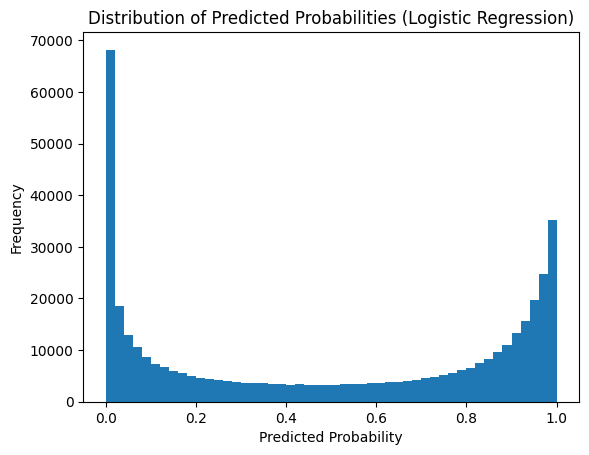

In [35]:
import matplotlib.pyplot as plt

# Extract probability of positive class
lr_probs = lr_preds.select("probability").toPandas()
lr_probs["p"] = lr_probs["probability"].apply(lambda x: float(x[1]))

# Plot distribution
plt.hist(lr_probs["p"], bins=50)
plt.title("Distribution of Predicted Probabilities (Logistic Regression)")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.show()

### 5.7.2 Final Model Selection

Based on the model comparison results, Logistic Regression is selected as the final model. It achieved a validation AUC of 0.9393, significantly outperforming Random Forest, which achieved an AUC of 0.8746.

The superior performance of Logistic Regression can be attributed to its ability to effectively leverage high-dimensional sparse TF-IDF features, which were shown to contribute the majority of predictive signal. In contrast, Random Forest underutilised the text component and relied more heavily on structured features, resulting in lower overall performance.

In addition to higher predictive accuracy, Logistic Regression offers greater interpretability through its coefficients, allowing for clearer understanding of feature effects. 

Therefore, Logistic Regression is chosen as the final model for predicting recommendation outcomes.

### 5.8 Practical Implications

The results of this study provide several practical insights for game developers and platform operators.

First, the strong importance of text-based features suggests that the content of user reviews plays a critical role in determining recommendation outcomes. This highlights the value of natural language processing techniques in extracting meaningful insights from user feedback. Platforms can leverage such models to automatically identify positive and negative sentiment, enabling better content moderation and recommendation systems.

Second, engagement-related features such as helpful votes and playtime are also key predictors. This suggests that reviews from highly engaged users or those that receive strong community interaction may carry greater informational value. Platforms can prioritise or highlight such reviews to improve user decision-making.

Third, the importance of application-level metrics such as overall recommendation rate indicates that collective user sentiment strongly influences individual behaviour. This suggests that maintaining a high overall rating is critical for game success, and developers should focus on consistently delivering positive user experiences.

Finally, the ability to predict recommendation outcomes accurately enables potential applications such as early detection of negative feedback, automated review summarisation, and targeted interventions to improve user satisfaction.

Overall, the findings demonstrate how combining textual and structured data can provide actionable insights for improving product quality and user engagement.